# Data Exploration: PCA-Driven Adaptive Sensor Triage
## Phase 1, Week 1 — Dataset Loading & Initial Exploration

**Datasets:**
1. Tennessee Eastman Process (TEP) — 52 sensors, fault detection
2. NASA IMS Bearing — vibration sensors, remaining useful life
3. SKAB (Skoltech Anomaly Benchmark) — 8 sensors, anomaly detection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
import os
import glob

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw')
print(f"Data directory: {DATA_DIR}")
print(f"Files: {os.listdir(DATA_DIR)}")

Data directory: /Users/ankithemantlade/Desktop/Research Paper PCA/data/raw
Files: ['.gitkeep', 'NASA_Bearings.zip', 'skab_repo', 'TEP_FaultFree_Training.RData', 'TEP_Faulty_Training.RData']


## 1. Tennessee Eastman Process (TEP)

The TEP simulates a real chemical plant with **52 sensors** (41 measured + 11 manipulated variables). It includes 20 different fault types plus normal operation. Each simulation run = 25 hours at 3-minute intervals (500 samples).

**Key for our research:** High-dimensional, correlated sensor data with known fault labels — ideal for testing PCA-based channel importance scoring.

In [2]:
# Load TEP fault-free training data
tep_ff = pyreadr.read_r(os.path.join(DATA_DIR, 'TEP_FaultFree_Training.RData'))
tep_ff_df = tep_ff[list(tep_ff.keys())[0]]

print(f"Shape: {tep_ff_df.shape}")
print(f"Columns ({len(tep_ff_df.columns)}): {list(tep_ff_df.columns)}")
print(f"\nSimulation runs: {tep_ff_df['simulationRun'].nunique()}")
print(f"Samples per run: {tep_ff_df.groupby('simulationRun')['sample'].count().iloc[0]}")
print(f"Fault numbers: {tep_ff_df['faultNumber'].unique()}")
print(f"\nMissing values:\n{tep_ff_df.isnull().sum().sum()}")
tep_ff_df.head()

Shape: (250000, 55)
Columns (55): ['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11']

Simulation runs: 500
Samples per run: 500
Fault numbers: [0.]

Missing values:
0


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [3]:
# Sensor variable descriptions (from TEP documentation)
SENSOR_NAMES = {
    'xmeas_1': 'A Feed (stream 1)',
    'xmeas_2': 'D Feed (stream 2)',
    'xmeas_3': 'E Feed (stream 3)',
    'xmeas_4': 'A+C Feed (stream 4)',
    'xmeas_5': 'Recycle Flow (stream 8)',
    'xmeas_6': 'Reactor Feed Rate (stream 6)',
    'xmeas_7': 'Reactor Pressure',
    'xmeas_8': 'Reactor Level',
    'xmeas_9': 'Reactor Temperature',
    'xmeas_10': 'Purge Rate (stream 9)',
    'xmeas_11': 'Separator Temperature',
    'xmeas_12': 'Separator Level',
    'xmeas_13': 'Separator Pressure',
    'xmeas_14': 'Separator Underflow (stream 10)',
    'xmeas_15': 'Stripper Level',
    'xmeas_16': 'Stripper Pressure',
    'xmeas_17': 'Stripper Underflow (stream 11)',
    'xmeas_18': 'Stripper Temperature',
    'xmeas_19': 'Stripper Steam Flow',
    'xmeas_20': 'Compressor Work',
    'xmeas_21': 'Reactor CW Outlet Temp',
    'xmeas_22': 'Separator CW Outlet Temp',
    'xmeas_23': 'Component A (stream 6)',
    'xmeas_24': 'Component D (stream 6)',
    'xmeas_25': 'Component E (stream 6)',
    'xmeas_26': 'Component F (stream 6)',
    'xmeas_27': 'Component A (stream 9)',
    'xmeas_28': 'Component B (stream 9)',
    'xmeas_29': 'Component C (stream 9)',
    'xmeas_30': 'Component D (stream 9)',
    'xmeas_31': 'Component E (stream 9)',
    'xmeas_32': 'Component F (stream 9)',
    'xmeas_33': 'Component G (stream 9)',
    'xmeas_34': 'Component H (stream 9)',
    'xmeas_35': 'Component D (stream 11)',
    'xmeas_36': 'Component E (stream 11)',
    'xmeas_37': 'Component F (stream 11)',
    'xmeas_38': 'Component G (stream 11)',
    'xmeas_39': 'Component H (stream 11)',
    'xmeas_40': 'Component D (stream 11) [2]',
    'xmeas_41': 'Component E (stream 11) [2]',
}

MV_NAMES = {
    'xmv_1': 'D Feed Flow (valve)',
    'xmv_2': 'E Feed Flow (valve)',
    'xmv_3': 'A Feed Flow (valve)',
    'xmv_4': 'A+C Feed Flow (valve)',
    'xmv_5': 'Compressor Recycle Valve',
    'xmv_6': 'Purge Valve (stream 9)',
    'xmv_7': 'Separator Pot Liquid Flow (valve)',
    'xmv_8': 'Stripper Liquid Product Flow (valve)',
    'xmv_9': 'Stripper Steam Valve',
    'xmv_10': 'Reactor CW Flow',
    'xmv_11': 'Condenser CW Flow',
}

print(f"Total sensor channels: {len(SENSOR_NAMES) + len(MV_NAMES)} ({len(SENSOR_NAMES)} measured + {len(MV_NAMES)} manipulated)")

Total sensor channels: 52 (41 measured + 11 manipulated)


In [4]:
# Summary statistics for all sensor channels
sensor_cols = [c for c in tep_ff_df.columns if c.startswith('xmeas_') or c.startswith('xmv_')]
tep_ff_df[sensor_cols].describe().round(3)

,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,...,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000,250000.000
mean,0.250,3663.786,4508.820,9.347,26.902,42.338,2705.038,75.000,120.400,0.337,...,53.974,24.639,61.299,22.217,40.055,38.099,46.534,47.959,41.104,18.119
std,0.031,34.006,39.215,0.086,0.211,0.219,7.526,0.542,0.019,0.013,...,0.470,3.038,1.244,0.530,1.527,2.965,2.351,2.717,0.541,1.464
min,0.122,3511.800,4336.900,8.973,25.951,41.394,2672.300,72.649,120.310,0.285,...,52.095,11.977,55.961,19.749,33.389,25.959,36.937,36.641,38.586,11.705
25%,0.230,3640.800,4482.400,9.289,26.758,42.188,2700.100,74.632,120.390,0.329,...,53.657,22.602,60.453,21.864,39.021,36.081,44.931,46.265,40.740,17.130
50%,0.251,3663.700,4508.800,9.347,26.902,42.338,2705.000,75.000,120.400,0.337,...,53.974,24.644,61.298,22.217,40.058,38.091,46.530,47.820,41.104,18.119
75%,0.271,3686.800,4535.300,9.405,27.046,42.487,2710.000,75.369,120.410,0.346,...,54.290,26.674,62.144,22.568,41.084,40.117,48.140,49.651,41.470,19.111
max,0.392,3808.400,4683.700,9.730,27.818,43.257,2739.100,77.514,120.480,0.395,...,56.118,38.351,66.443,24.525,47.498,50.729,56.443,59.616,43.930,24.762


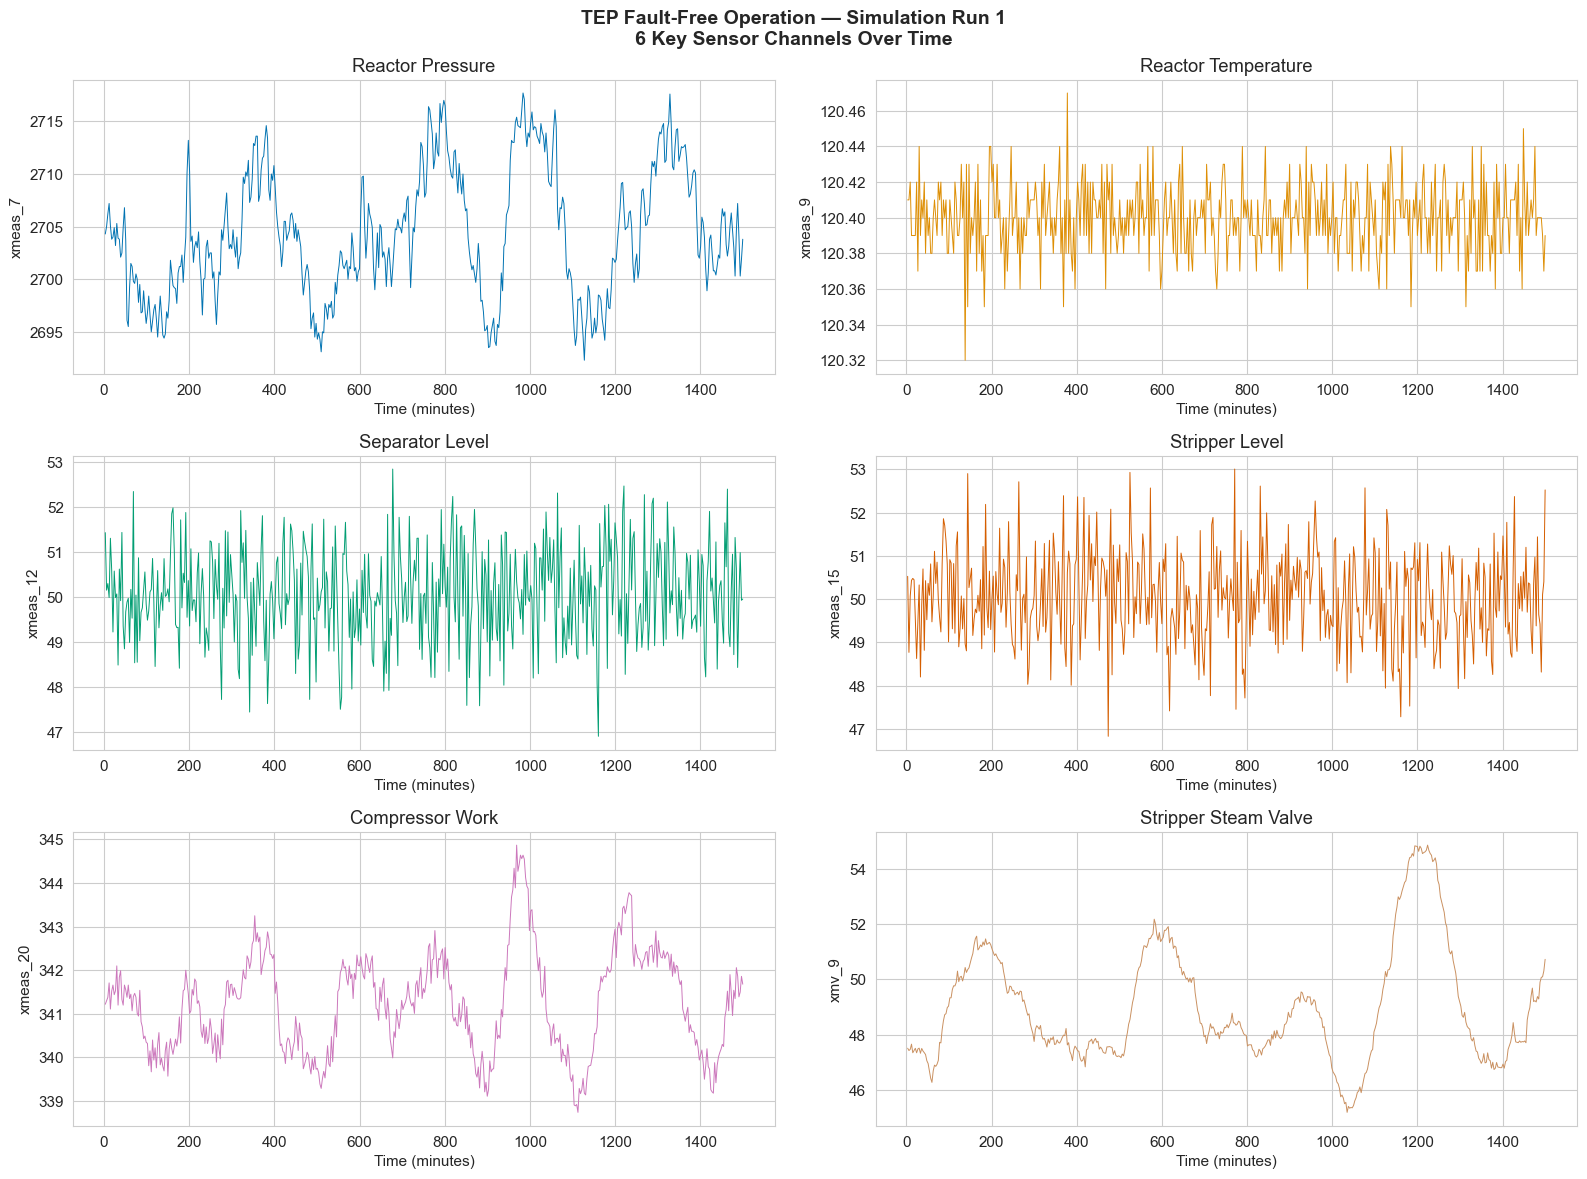

Saved to paper/figures/tep_sensor_overview.png


In [5]:
# Plot 6 key sensor channels over time for a single simulation run
run1 = tep_ff_df[tep_ff_df['simulationRun'] == 1].copy()
time_minutes = run1['sample'] * 3  # 3-minute intervals

channels_to_plot = ['xmeas_7', 'xmeas_9', 'xmeas_12', 'xmeas_15', 'xmeas_20', 'xmv_9']
channel_labels = [
    'Reactor Pressure', 'Reactor Temperature', 'Separator Level',
    'Stripper Level', 'Compressor Work', 'Stripper Steam Valve'
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('TEP Fault-Free Operation — Simulation Run 1\n6 Key Sensor Channels Over Time', fontsize=14, fontweight='bold')

for idx, (col, label) in enumerate(zip(channels_to_plot, channel_labels)):
    ax = axes[idx // 2, idx % 2]
    ax.plot(time_minutes, run1[col], linewidth=0.7, color=sns.color_palette('colorblind')[idx])
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel(col)
    ax.set_title(label)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'paper', 'figures', 'tep_sensor_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to paper/figures/tep_sensor_overview.png")

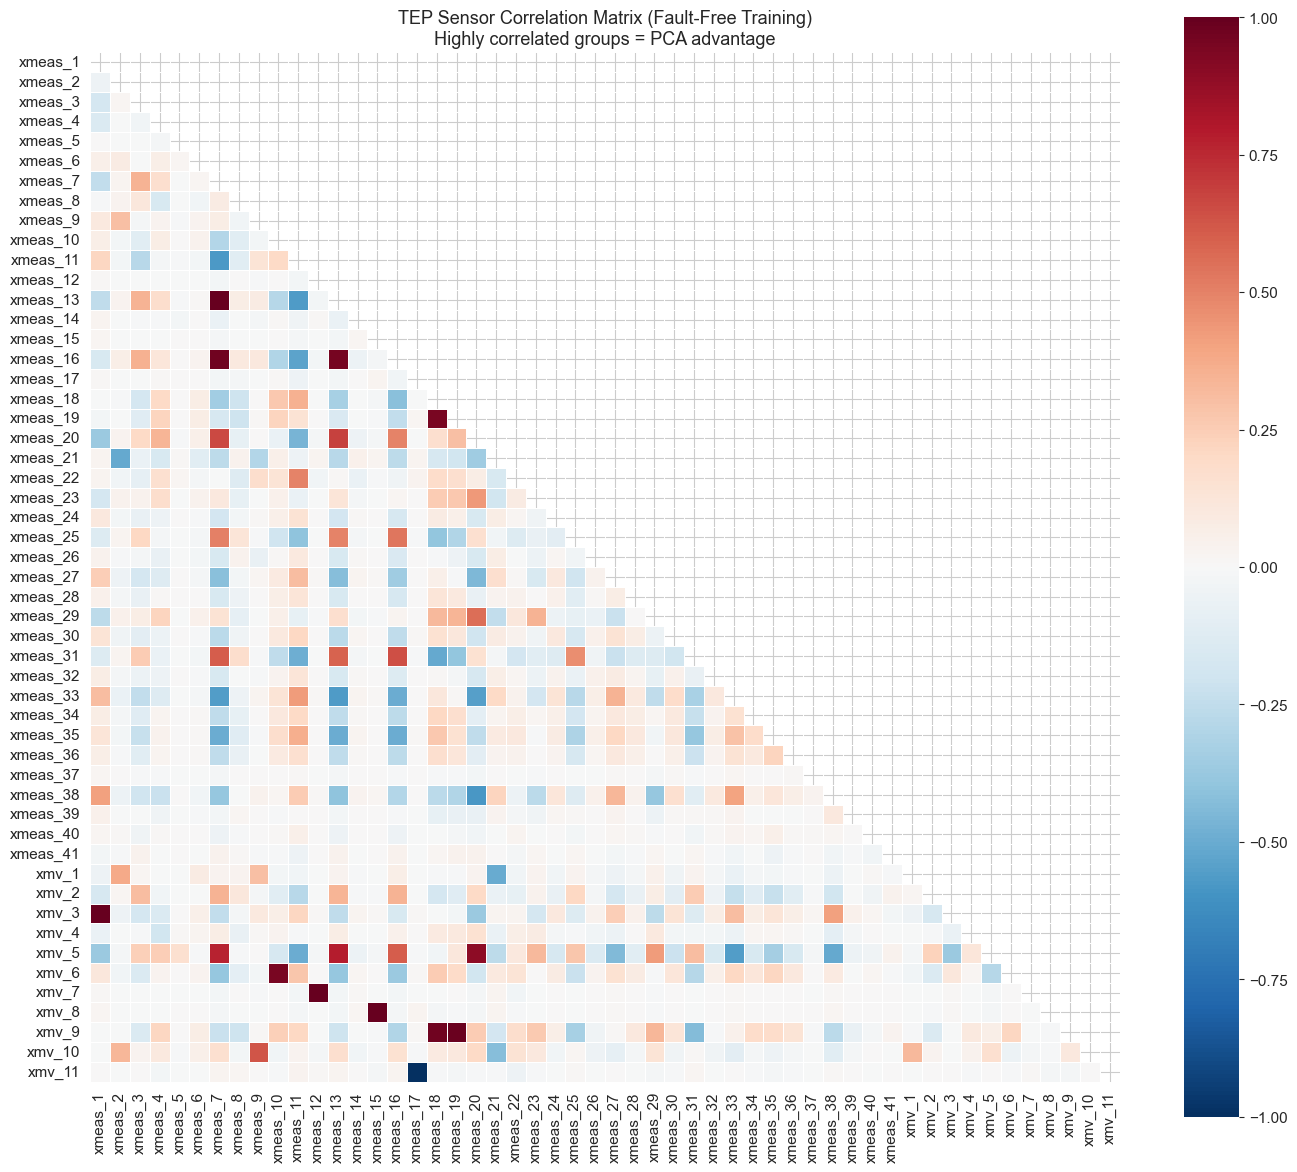


Strongly correlated pairs (|r| > 0.7): 14
Total possible pairs: 1326
Ratio: 1.1%


In [6]:
# Correlation matrix of TEP sensors — key insight for PCA-based approach
# Highly correlated channels = PCA advantage over raw variance
fig, ax = plt.subplots(figsize=(14, 12))
corr = tep_ff_df[sensor_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('TEP Sensor Correlation Matrix (Fault-Free Training)\nHighly correlated groups = PCA advantage', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'paper', 'figures', 'tep_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Count strongly correlated pairs
strong_corr = (corr.abs() > 0.7).sum().sum() - len(sensor_cols)  # subtract diagonal
print(f"\nStrongly correlated pairs (|r| > 0.7): {strong_corr // 2}")
print(f"Total possible pairs: {len(sensor_cols) * (len(sensor_cols)-1) // 2}")
print(f"Ratio: {strong_corr / (len(sensor_cols) * (len(sensor_cols)-1)):.1%}")

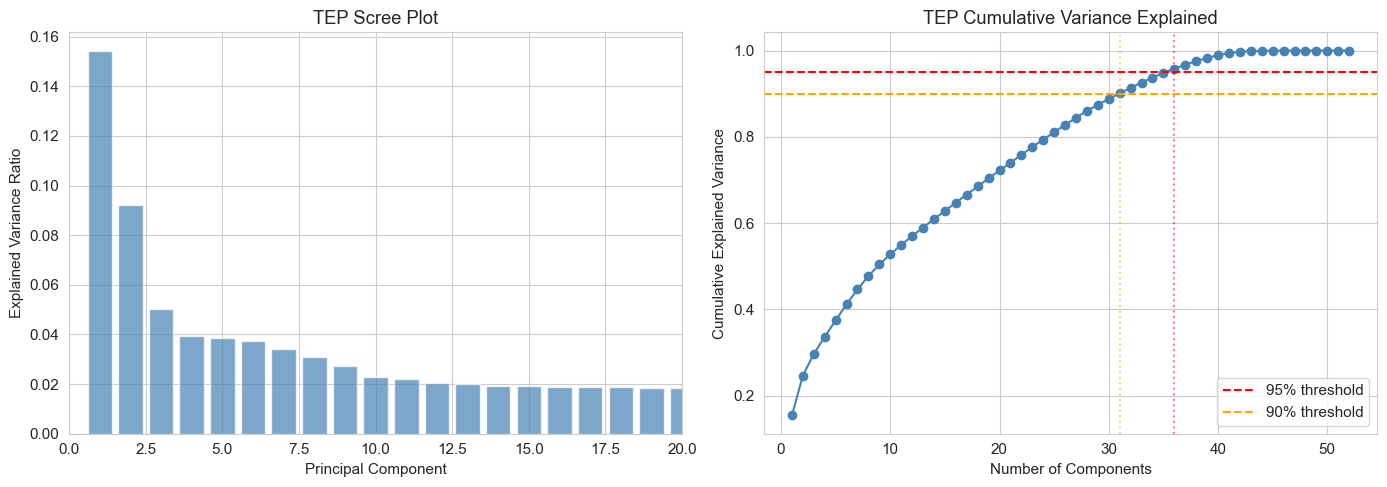

Components for 90% variance: 31 (out of 52 sensors)
Components for 95% variance: 36 (out of 52 sensors)
→ 16 channels contain < 5% of the information — strong case for PCA triage


In [7]:
# PCA variance explained — how many components capture most variance?
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(tep_ff_df[sensor_cols].dropna())

pca = PCA()
pca.fit(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('TEP Scree Plot')
ax1.set_xlim(0, 20)

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax2.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='steelblue')
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
ax2.axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
k_95 = np.argmax(cumvar >= 0.95) + 1
k_90 = np.argmax(cumvar >= 0.90) + 1
ax2.axvline(x=k_95, color='red', linestyle=':', alpha=0.5)
ax2.axvline(x=k_90, color='orange', linestyle=':', alpha=0.5)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('TEP Cumulative Variance Explained')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {k_90} (out of {len(sensor_cols)} sensors)")
print(f"Components for 95% variance: {k_95} (out of {len(sensor_cols)} sensors)")
print(f"→ {len(sensor_cols) - k_95} channels contain < 5% of the information — strong case for PCA triage")

## 2. SKAB (Skoltech Anomaly Benchmark)

SKAB monitors a water circulation testbed with **8 sensors** (accelerometers, current, pressure, temperature, thermocouple, voltage, flow rate). It contains 35 CSV files across anomaly-free, valve1, valve2, and other fault scenarios.

**Key for our research:** Smaller sensor count, real physical system, labeled anomalies — good for testing adaptivity under fault onset.

In [8]:
# Load and explore SKAB dataset
SKAB_DIR = os.path.join(DATA_DIR, 'skab_repo', 'data')

# Load all valve1 files as example
skab_files = sorted(glob.glob(os.path.join(SKAB_DIR, 'valve1', '*.csv')))
print(f"SKAB valve1 files: {len(skab_files)}")

# Load first file
skab_sample = pd.read_csv(skab_files[0], sep=';', parse_dates=['datetime'], index_col='datetime')
print(f"\nSample file shape: {skab_sample.shape}")
print(f"Columns: {list(skab_sample.columns)}")
print(f"Date range: {skab_sample.index.min()} to {skab_sample.index.max()}")
print(f"Sampling rate: ~{(skab_sample.index[1] - skab_sample.index[0]).total_seconds():.0f}s")
print(f"\nAnomaly distribution:\n{skab_sample['anomaly'].value_counts()}")
skab_sample.head()

SKAB valve1 files: 16

Sample file shape: (1147, 10)
Columns: ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'anomaly', 'changepoint']
Date range: 2020-03-09 10:14:33 to 2020-03-09 10:34:32
Sampling rate: ~1s

Anomaly distribution:
anomaly
0.0    746
1.0    401
Name: count, dtype: int64


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
datetime,,,,,,,,,,
2020-03-09 10:14:33,0.026588,0.040111,1.33020,0.054711,79.3366,26.0199,233.062,32.0,0.0,0.0
2020-03-09 10:14:34,0.026170,0.040453,1.35399,0.382638,79.5158,26.0258,236.040,32.0,0.0,0.0
2020-03-09 10:14:35,0.026199,0.039419,1.54006,0.710565,79.3756,26.0265,251.380,32.0,0.0,0.0
2020-03-09 10:14:36,0.026027,0.039641,1.33458,0.382638,79.6097,26.0393,234.392,32.0,0.0,0.0
2020-03-09 10:14:37,0.026290,0.040273,1.07851,-0.273216,79.6109,26.0420,225.342,32.0,0.0,0.0


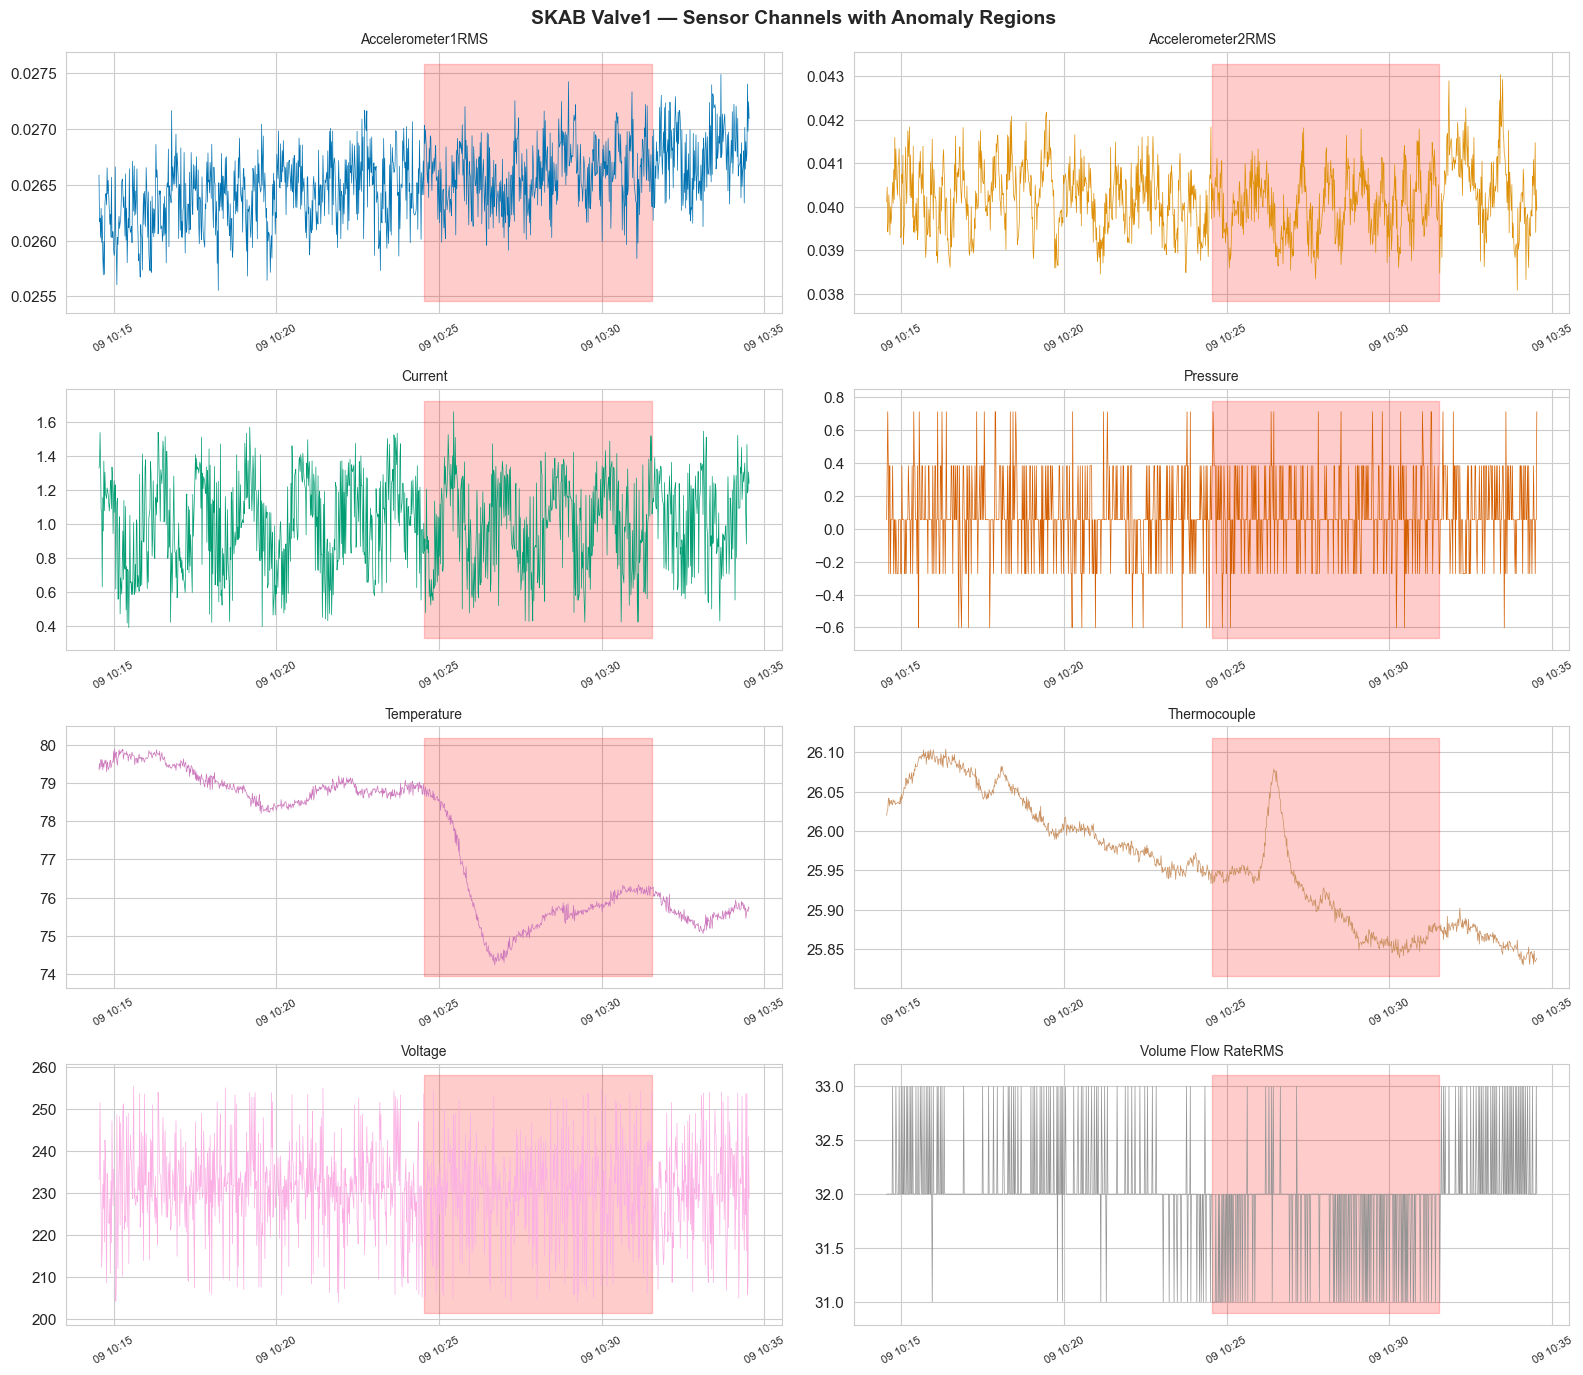

In [9]:
# Plot SKAB sensors with anomaly regions highlighted
skab_sensor_cols = [c for c in skab_sample.columns if c not in ['anomaly', 'changepoint']]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('SKAB Valve1 — Sensor Channels with Anomaly Regions', fontsize=14, fontweight='bold')

for idx, col in enumerate(skab_sensor_cols):
    ax = axes[idx // 2, idx % 2]
    ax.plot(skab_sample.index, skab_sample[col], linewidth=0.5, color=sns.color_palette('colorblind')[idx % 8])
    
    # Highlight anomaly regions
    anomaly_mask = skab_sample['anomaly'] == 1
    if anomaly_mask.any():
        ax.fill_between(skab_sample.index, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=anomaly_mask, alpha=0.2, color='red', label='Anomaly')
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'paper', 'figures', 'skab_sensor_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. NASA IMS Bearing Dataset

The IMS dataset contains vibration signals from 4 bearings monitored until failure. Each file contains 20,480 data points (1-second snapshots at 20 kHz). Three test runs with different failure modes: inner race, roller element, and outer race defects.

**Key for our research:** High-frequency vibration data, RUL (Remaining Useful Life) prediction task — tests scalability to high sample-rate sensors.

*Note: This dataset is large (~6 GB). Loading will be done after download completes.*

In [10]:
# NASA Bearing dataset — load after download
# Check if download is complete
nasa_zip = os.path.join(DATA_DIR, 'NASA_Bearings.zip')
if os.path.exists(nasa_zip):
    import zipfile
    print(f"NASA Bearings ZIP size: {os.path.getsize(nasa_zip) / 1e6:.1f} MB")
    
    # Extract to data/raw/nasa_bearings/
    nasa_dir = os.path.join(DATA_DIR, 'nasa_bearings')
    if not os.path.exists(nasa_dir):
        print("Extracting...")
        with zipfile.ZipFile(nasa_zip, 'r') as z:
            z.extractall(nasa_dir)
        print("Done!")
    
    # List the test directories
    for root, dirs, files in os.walk(nasa_dir):
        depth = root.replace(nasa_dir, '').count(os.sep)
        indent = ' ' * 2 * depth
        print(f'{indent}{os.path.basename(root)}/')
        if depth < 2:
            subindent = ' ' * 2 * (depth + 1)
            file_count = len(files)
            if file_count > 0:
                print(f'{subindent}{file_count} files')
else:
    print(f"NASA Bearings not yet downloaded. Check {nasa_zip}")

NASA Bearings ZIP size: 1075.6 MB
Extracting...


Done!
nasa_bearings/
  4. Bearings/
    1 files


## Summary: Dataset Comparison

| Property | TEP | NASA Bearing | SKAB |
|----------|-----|-------------|------|
| **Sensors** | 52 (41 meas + 11 manip) | 4-8 accelerometers | 8 sensors |
| **Samples** | 250K+ (500 runs × 500 steps) | ~984 files × 20K points | ~3.6K per file × 35 files |
| **Task** | Fault detection (20 types) | RUL prediction | Anomaly detection |
| **Sampling** | 3 min intervals | 20 kHz (1s snapshots every 10 min) | 1s intervals |
| **Labels** | Fault type (0-20) | Time-to-failure | Anomaly + changepoint |
| **Key value** | High-dim, correlated | High-frequency, degradation | Real system, labeled regions |